<a href="https://colab.research.google.com/github/MuhammadAqsandy/Practical-Statistics-for-Data-Scientist-Books/blob/main/PracticalStatisticsChapter3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 3 – Statistical Experiments & Significance Testing

## 📖 Summary
Chapter 3 covers the design and analysis of **statistical experiments**, with emphasis on A/B testing, hypothesis testing, and understanding p-values and significance in the context of data science.

### Key Topics Covered:
1. **A/B Testing** – treatment vs. control, random assignment
2. **Hypothesis Testing** – null hypothesis, alternative hypothesis
3. **Resampling** – permutation tests as a distribution-free alternative
4. **Statistical Significance** – p-value, alpha level
5. **t-Tests** – comparing two group means
6. **Multiple Testing** – p-value inflation, Bonferroni correction
7. **ANOVA** – comparing means across multiple groups
8. **Chi-Square Test** – testing categorical independence


## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from itertools import combinations
np.random.seed(42)
print("Libraries loaded ✓")


Libraries loaded ✓


## 2. A/B Test Simulation

In [2]:
# Simulate click-through rates
n_A, n_B = 2000, 2000
p_A, p_B = 0.40, 0.44   # true conversion rates

clicks_A = np.random.binomial(1, p_A, n_A)
clicks_B = np.random.binomial(1, p_B, n_B)

rate_A = clicks_A.mean()
rate_B = clicks_B.mean()
lift = (rate_B - rate_A) / rate_A * 100

print(f"Group A conversion: {rate_A:.4f} ({rate_A*100:.2f}%)")
print(f"Group B conversion: {rate_B:.4f} ({rate_B*100:.2f}%)")
print(f"Lift:               {lift:.2f}%")


Group A conversion: 0.4085 (40.85%)
Group B conversion: 0.4380 (43.80%)
Lift:               7.22%


## 3. Permutation Test

Observed difference: 0.0295
Permutation p-value: 0.0730


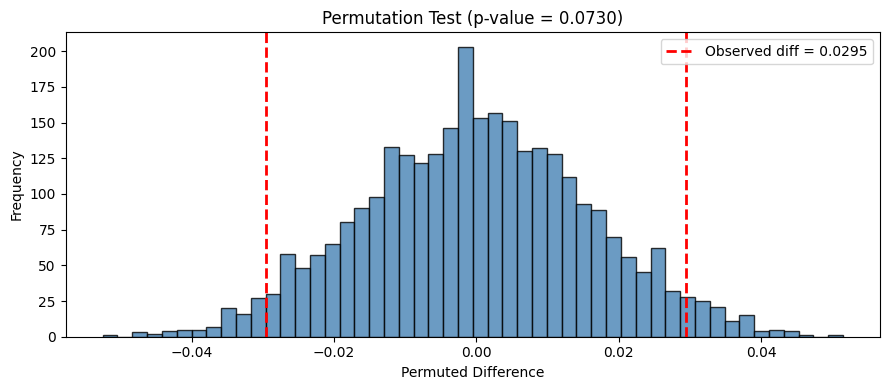

In [3]:
# Observed difference
obs_diff = rate_B - rate_A
print(f"Observed difference: {obs_diff:.4f}")

# Permutation test
combined = np.concatenate([clicks_A, clicks_B])
perm_diffs = []
for _ in range(3000):
    perm = np.random.permutation(combined)
    perm_diffs.append(perm[:n_A].mean() - perm[n_A:].mean())

p_value = np.mean(np.abs(perm_diffs) >= np.abs(obs_diff))
print(f"Permutation p-value: {p_value:.4f}")

plt.figure(figsize=(9, 4))
plt.hist(perm_diffs, bins=50, color='steelblue', edgecolor='black', alpha=0.8)
plt.axvline(obs_diff, color='red', linestyle='--', linewidth=2, label=f'Observed diff = {obs_diff:.4f}')
plt.axvline(-obs_diff, color='red', linestyle='--', linewidth=2)
plt.xlabel('Permuted Difference')
plt.ylabel('Frequency')
plt.title(f'Permutation Test (p-value = {p_value:.4f})')
plt.legend()
plt.tight_layout()
plt.savefig('ch3_permutation.png', dpi=100, bbox_inches='tight')
plt.show()


### 📚 Theory: Permutation Test
A **permutation test** (randomization test) computes the p-value by:
1. Randomly shuffling group labels thousands of times
2. Computing the test statistic each time
3. Counting how often the permuted statistic is as extreme as the observed one

It makes **no distributional assumption** and is exact for small samples.

$$p	ext{-value} = \frac{\#\{|\delta_{perm}| \geq |\delta_{obs}|\}}{N_{permutations}}$$


## 4. Two-Sample t-Test

t-statistic: -1.6372
p-value:     0.1032
Significant (α=0.05): False


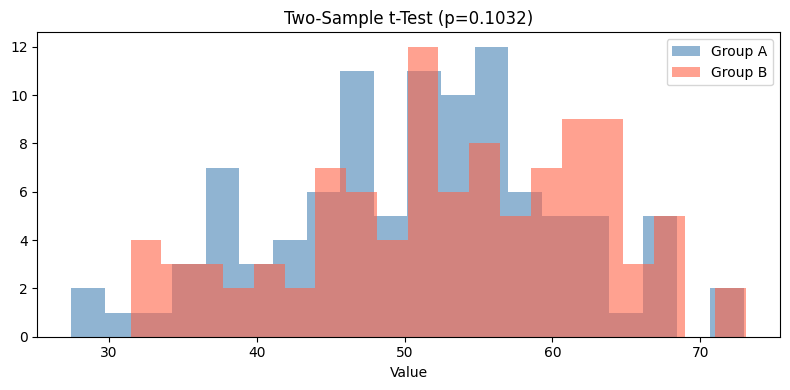

In [4]:
# Two independent groups
group_A = np.random.normal(loc=50, scale=10, size=100)
group_B = np.random.normal(loc=53, scale=10, size=100)

t_stat, p_val = stats.ttest_ind(group_A, group_B)
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value:     {p_val:.4f}")
print(f"Significant (α=0.05): {p_val < 0.05}")

# Visualize
plt.figure(figsize=(8, 4))
plt.hist(group_A, bins=20, alpha=0.6, label='Group A', color='steelblue')
plt.hist(group_B, bins=20, alpha=0.6, label='Group B', color='tomato')
plt.xlabel('Value')
plt.title(f'Two-Sample t-Test (p={p_val:.4f})')
plt.legend()
plt.tight_layout()
plt.savefig('ch3_ttest.png', dpi=100, bbox_inches='tight')
plt.show()


### 📚 Theory: t-Test
The **two-sample t-test** tests whether two group means differ significantly:

$$t = \frac{\bar{x}_A - \bar{x}_B}{s_p \sqrt{\frac{1}{n_A} + \frac{1}{n_B}}}$$

- **Null hypothesis** $H_0$: $\mu_A = \mu_B$ (no difference)
- **Alternative** $H_1$: $\mu_A \neq \mu_B$
- If $p < \alpha$ (e.g. 0.05), reject $H_0$

**p-value** = probability of observing a result at least as extreme as the data, assuming $H_0$ is true. A small p-value is evidence *against* $H_0$, not proof of the alternative.


## 5. ANOVA – Multiple Group Comparison

F-statistic: 23.3920
p-value:     0.000000


/tmp/ipykernel_4135/2889101682.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([ctrl, treat1, treat2], labels=['Control','Treatment 1','Treatment 2'],


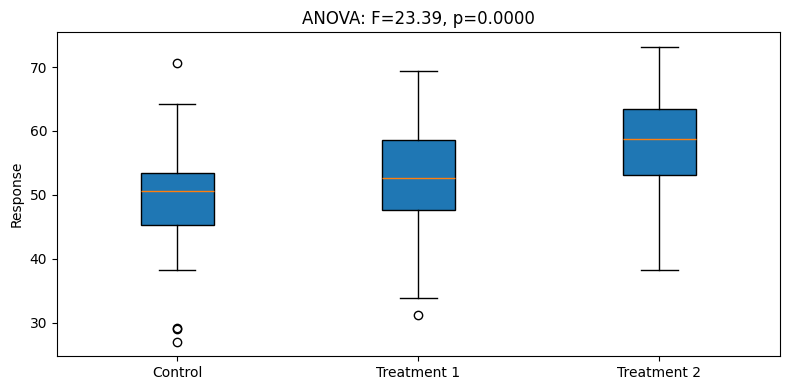

In [5]:
# 3 groups
ctrl  = np.random.normal(50, 8, 80)
treat1 = np.random.normal(53, 8, 80)
treat2 = np.random.normal(57, 8, 80)

f_stat, p_val = stats.f_oneway(ctrl, treat1, treat2)
print(f"F-statistic: {f_stat:.4f}")
print(f"p-value:     {p_val:.6f}")

plt.figure(figsize=(8, 4))
plt.boxplot([ctrl, treat1, treat2], labels=['Control','Treatment 1','Treatment 2'],
            patch_artist=True)
plt.ylabel('Response')
plt.title(f'ANOVA: F={f_stat:.2f}, p={p_val:.4f}')
plt.tight_layout()
plt.savefig('ch3_anova.png', dpi=100, bbox_inches='tight')
plt.show()


## 6. Chi-Square Test

In [6]:
# Contingency table: Click vs. Ad Type
observed = np.array([[200, 150],
                     [300, 400]])

chi2, p, dof, expected = stats.chi2_contingency(observed)
print(f"Chi2 statistic: {chi2:.4f}")
print(f"p-value:        {p:.4f}")
print(f"Degrees of freedom: {dof}")
print(f"Expected table:\n{expected.round(1)}")


Chi2 statistic: 18.5225
p-value:        0.0000
Degrees of freedom: 1
Expected table:
[[166.7 183.3]
 [333.3 366.7]]


### 📚 Theory: Chi-Square Test
The **chi-square test** checks whether two categorical variables are independent:

$$\chi^2 = \sum \frac{(O_i - E_i)^2}{E_i}$$

- $O_i$ = observed count, $E_i$ = expected count under independence
- Large $\chi^2$ → strong evidence against independence

### 📚 Multiple Testing Problem
Running many tests inflates the chance of a false positive. With $m$ tests at $\alpha = 0.05$:
$$P(\text{at least 1 false positive}) = 1 - (1-0.05)^m$$

**Bonferroni correction**: use $\alpha^* = \alpha / m$ per test.


## ✅ Chapter 3 Summary

| Test | When to Use | Assumptions |
|---|---|---|
| Permutation Test | Any metric, no dist. assumptions | — |
| t-Test | Compare 2 means | Normality, equal variance |
| ANOVA | Compare 3+ means | Normality, equal variance |
| Chi-Square | Categorical independence | Expected count ≥ 5 |

**Key takeaway**: Statistical significance ≠ practical significance. Always check **effect size** and **business impact**, not just p-values.
